# DSTS 11523 · Week 4 Tutorial
## Model Evaluation and Optimisation

Run **top to bottom**. Each part has a short note, then code.

**What you will do**
1. Compute precision / recall by hand, and see why accuracy can lie
2. Use cross-validation, and fix data leakage with a Pipeline
3. Diagnose underfit vs overfit, then tune with GridSearch
4. Check which features help, and where the model fails
5. Log runs with MLflow


### Setup
Install once if needed: `pip install scikit-learn pandas mlflow scipy matplotlib`

This is a Yes/No (classification) problem: **is this tumour cancer?**

**In sklearn's raw file:** `0 = malignant (cancer)`, `1 = benign`.  
That makes cancer label **0**, but sklearn metrics treat **1** as the positive class by default — awkward.

So we **flip** the labels in Setup:

- **Positive (`y = 1`) = malignant = cancer** — the class we want to catch  
- **Negative (`y = 0`) = benign** — not cancer (~63% of cases)

After the flip, **positive is label 1**, not 0. About **37%** of cases are cancer.

Think of it like "will it rain tomorrow?": we care about the smaller class.

- **Precision:** when the model says cancer, how often is it really cancer?
- **Recall:** of the real cancers, how many did we catch?
- **F1:** one number that mixes both.


In [ ]:
# ============================================================
# 1. Basics — tools we use in almost every notebook
# ============================================================
import warnings                  # turn off extra warning messages so output is easier to read
import numpy as np               # work with numbers and lists of numbers
import pandas as pd              # work with tables (like a spreadsheet)
import matplotlib.pyplot as plt  # draw graphs

warnings.filterwarnings("ignore")
np.random.seed(42)  # same random numbers each run, so results match

# ============================================================
# 2. Data and how we split / test the model
# ============================================================
from sklearn.datasets import load_breast_cancer  # ready-made dataset: tumour measurements → cancer or not

from sklearn.model_selection import (
    train_test_split,   # split data: one part to train, one part to test (held back)
    StratifiedKFold,    # split into 5 groups; each group keeps the same cancer / benign mix
    cross_val_score,    # train and score the model on each group, then average
    validation_curve,   # change one setting (e.g. tree depth); plot train vs validation scores to see if the model is too simple or too detailed
    GridSearchCV,       # try many settings and pick the one with the best average score/performance
)

# ============================================================
# 3. Models that predict cancer or benign (classifiers)
# ============================================================
# Random forest: builds many decision trees, then takes a majority vote.
# Using many trees usually gives a more stable answer than one tree.
from sklearn.ensemble import RandomForestClassifier

# Dummy model: a "naive" guess, e.g. always pick the most common class.
# Use it as a benchmark. A real model should beat this.
from sklearn.dummy import DummyClassifier

# Logistic regression: a simple straight-line model.
# It outputs a probability, like "80% chance this is cancer".
from sklearn.linear_model import LogisticRegression

# ============================================================
# 4. Clean the data and join steps together
# ============================================================
# Pipeline: put several steps in a row (e.g. scale the numbers, then train the model).
# They are trained and tested as one unit, so we do not accidentally "cheat".
from sklearn.pipeline import Pipeline

# StandardScaler: make every column use a similar scale
# (average becomes 0). Needed for logistic regression to work fairly.
from sklearn.preprocessing import StandardScaler

# ============================================================
# 5. Pick the most useful columns
# ============================================================
# SelectKBest: keep only the K columns that best help predict cancer vs benign.
from sklearn.feature_selection import SelectKBest

# f_classif: the score SelectKBest uses to rank columns for cancer vs benign.
from sklearn.feature_selection import f_classif

# ============================================================
# 6. Scores — how good is the model?
# ============================================================
from sklearn.metrics import (
    confusion_matrix,   # a 2x2 table: correct cancer, correct benign, and both kinds of mistakes
    precision_score,    # when the model says cancer, how often is it really cancer?
    recall_score,       # of all real cancers, how many did the model find?
    accuracy_score,     # overall: what % of guesses were correct? (can look good even if we miss cancer)
    roc_auc_score,      # how well the model ranks "more likely cancer" vs "more likely benign" (1.0 is perfect)
    f1_score,           # one number that mixes precision and recall — useful because cancer is less common
    RocCurveDisplay,    # a graph of those ranking scores
)

X, y = load_breast_cancer(as_frame=True, return_X_y=True)  # X = measurements
# sklearn: 0 = malignant, 1 = benign. Flip so 1 = cancer (positive class).
y = (y == 0).astype(int)  # 1 = malignant (cancer), 0 = benign
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)  # 80% train, 20% test; both sets keep the same mix of cancer / benign

print("shape:", X.shape)
print("positive rate (malignant = 1):", round(y.mean(), 3))
print("train:", X_train.shape, "| test:", X_test.shape)


shape: (569, 30)
positive rate (malignant = 1): 0.373
train: (455, 30) | test: (114, 30)


---
## Part 1 · Metrics — do not trust accuracy alone

Every score comes from four counts:

| | Predicted benign | Predicted cancer |
|---|---|---|
| **True benign** | TN | FP (false cancer alarm) |
| **True cancer** | FN (missed cancer) | TP |

**Positive class = malignant (cancer).** Benign is the negative class.

- **Precision** = TP / (TP + FP) — when we say cancer, how often are we right?
- **Recall** = TP / (TP + FN) — of the real cancers, how many did we catch?
- **F1** balances precision and recall
- **ROC-AUC** — the model scores each case from "most likely cancer" to "least likely cancer". A high AUC means real cancers sit near the top of that list (1.0 is perfect). It does not use the usual 0.5 cut-off.


### Exercise 1 — Precision and recall by hand
Train a random forest. Read the confusion matrix. Compute precision and recall with simple division. Check they match sklearn.


In [ ]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

cm = confusion_matrix(y_test, pred)
TN, FP, FN, TP = cm.ravel() #The .ravel() method reads the 2D matrix row-by-row, from left to right, and flattens it out into a continuous, 
#flat 1D sequence of numbers

print("confusion matrix [[TN, FP], [FN, TP]]:", cm.tolist())
print("precision  manual:", round(TP / (TP + FP), 4), "| sklearn:", round(precision_score(y_test, pred), 4))
print("recall     manual:", round(TP / (TP + FN), 4), "| sklearn:", round(recall_score(y_test, pred), 4))


confusion matrix [[TN, FP], [FN, TP]]: [[72, 0], [3, 39]]
precision  manual: 1.0 | sklearn: 1.0
recall     manual: 0.9286 | sklearn: 0.9286


**Takeaway:** sklearn is doing this same arithmetic. **Positive = cancer.** TN = correct benign, TP = correct cancer, FN = missed cancer, FP = false cancer alarm.


### Exercise 2 — The accuracy trap
A dummy model always predicts the majority class (benign). Compare **accuracy** vs **recall for cancer** (class 1, the positive class).


In [ ]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dp = dummy.predict(X_test)

print("dummy  accuracy          :", round(accuracy_score(y_test, dp), 4))
print("dummy  recall CANCER  :", round(recall_score(y_test, dp), 4))
print("forest recall CANCER  :", round(recall_score(y_test, pred), 4))


dummy  accuracy          : 0.6316
dummy  recall CANCER  : 0.0
forest recall CANCER  : 0.9286


**Takeaway:** ~63% accuracy while catching **zero** cancers. Accuracy looks fine; the model is useless. On unbalanced data, use recall / F1 / AUC for **cancer** — not accuracy alone.


### Exercise 3 — Compare models with ROC-AUC
AUC does not depend on the 0.5 threshold, so it is a fair one-number comparison. Here it ranks "more likely cancer" vs "more likely benign".

**Labels (after Setup flip):** positive = **1 = cancer**. (sklearn's raw file uses 0 = cancer; we flipped it.)

Logistic regression needs scaled features, so we wrap it in a **Pipeline**. Re-fit the random forest here too, so both models use the same labels.


classes (0, 1) = [0 1] → positive class 1 = cancer
Random Forest AUC : 0.9944
Logistic Reg  AUC : 0.996


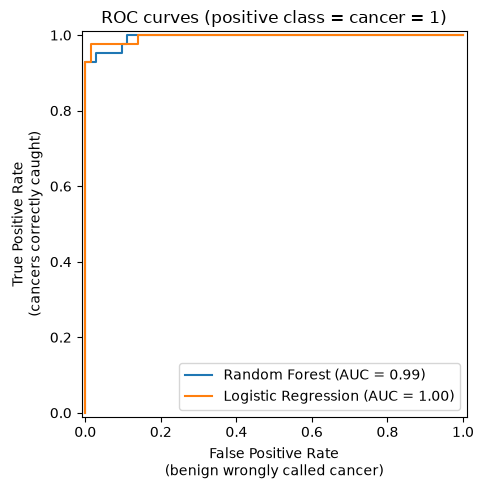

In [ ]:
# Both models must be trained on the flipped labels (1 = cancer, 0 = benign)
rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)
pred = rf.predict(X_test)  # keep pred in sync for later cells

lr = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000)),
])
lr.fit(X_train, y_train)

# [:, 1] = probability of class 1 = cancer (our positive class)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print("classes (0, 1) =", rf.classes_, "→ positive class 1 = cancer")
print("Random Forest AUC :", round(rf_auc, 4))
print("Logistic Reg  AUC :", round(lr_auc, 4))

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name="Random Forest", pos_label=1)
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name="Logistic Regression", pos_label=1)

# Axis titles are standard ROC names. With positive = cancer (1):
#   y = True Positive Rate  = of real cancers, how many we catch (recall)
#   x = False Positive Rate = of real benign cases, how many we wrongly call cancer
ax.set_xlabel("False Positive Rate\n(benign wrongly called cancer)")
ax.set_ylabel("True Positive Rate\n(cancers correctly caught)")
ax.set_title("ROC curves (positive class = cancer = 1)")
plt.tight_layout()
plt.show()


**Takeaway:** both models are strong. The simpler logistic regression can match (or beat) the forest. Always keep a simple baseline.


---
## Part 2 · Trustworthy estimates — CV and leakage

One train/test split is a coin flip. **Cross-validation** repeats the split and gives mean ± std.

**Leakage:** anything that learns from data (scaling, filling missing values, picking features) must happen **inside** each CV fold. A `Pipeline` does this for you.


### Exercise 4 — Put an error bar on the score
5-fold stratified CV. Report F1 as **mean ± std**.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y, cv=cv, scoring="f1")

print("per-fold:", np.round(scores, 4))
print(f"mean {scores.mean():.4f}  ±  {scores.std():.4f}")


per-fold: [0.9545 0.9    0.9383 0.9333 0.9512]
mean 0.9355  ±  0.0194


**Takeaway:** always report mean ± std. If two models differ by less than one std, treat them as tied.


### Exercise 5 — Spot the leak
Below, the labels are **random** (no real signal). Score should be ~0.5.

**Wrong:** pick the 20 "best" features using **all** rows, then cross-validate.
**Right:** put `SelectKBest` **inside** a Pipeline so it is redone on each training fold.


In [ ]:
rng = np.random.RandomState(0)
Xn = rng.randn(200, 1000)       # 1000 noise features
yn = rng.randint(0, 2, 200)     # random labels — no signal

# WRONG: selection saw every row's label
corr = np.abs([np.corrcoef(Xn[:, j], yn)[0, 1] for j in range(Xn.shape[1])])
top = np.argsort(corr)[-20:]
leaky = cross_val_score(LogisticRegression(max_iter=1000), Xn[:, top], yn, cv=5)

# RIGHT: selection happens inside each training fold
pipe = Pipeline([
    ("select", SelectKBest(f_classif, k=20)),
    ("clf", LogisticRegression(max_iter=1000)),
])
honest = cross_val_score(pipe, Xn, yn, cv=5)

print("leaky :", round(leaky.mean(), 4), "  <- looks useful (it is not)")
print("honest:", round(honest.mean(), 4), "  <- about chance")


leaky : 0.735   <- looks useful (it is not)
honest: 0.485   <- about chance


**Takeaway:** the leaky version can look like 70%+ on pure noise. Wrap every fitted step in a Pipeline. Never `fit` on data before you split.


---
## Part 3 · Diagnose and tune

Plot **train vs validation** as we let the model learn more detail (here: deeper trees):
- both **low and close** → underfit (too simple)
- **big gap** (train high, validation stuck) → overfit (too complex)
- Overfitting: The model learns the training data too well, including all its random noise and quirks. It performs great on training data but poorly on test data.
- Underfitting: The model is too simple to learn the underlying pattern in the data. It performs poorly on both training and test data.

Tune on **CV**, not on the test set.


### Exercise 6 — Bias vs variance (`max_depth`)
Sweep tree depth. Watch the train/validation gap.


   depth   train   valid     gap
       1   0.903   0.880   0.023
       2   0.949   0.925   0.024
       3   0.972   0.929   0.042
       5   0.993   0.933   0.060
       8   1.000   0.935   0.065
      12   1.000   0.936   0.064
    None   1.000   0.936   0.064


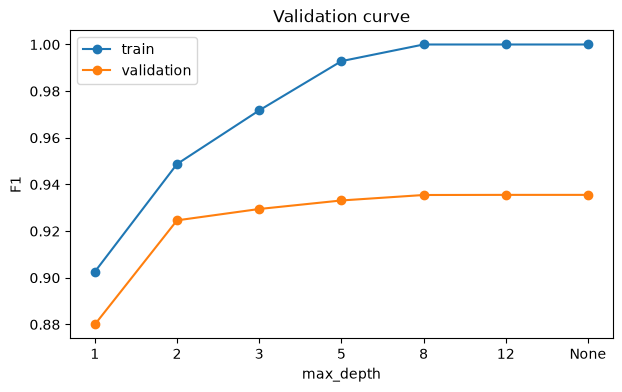

In [ ]:
depths = [1, 2, 3, 5, 8, 12, None]
train_s, valid_s = validation_curve(
    RandomForestClassifier(n_estimators=150, random_state=42),
    X, y,
    param_name="max_depth",
    param_range=depths,
    cv=cv,
    scoring="f1",
)

print(f"{'depth':>8}  {'train':>6}  {'valid':>6}  {'gap':>6}")
for d, a, b in zip(depths, train_s.mean(axis=1), valid_s.mean(axis=1)):
    print(f"{str(d):>8}  {a:6.3f}  {b:6.3f}  {a - b:6.3f}")

x_labels = [str(d) for d in depths]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_labels, train_s.mean(axis=1), marker="o", label="train")
ax.plot(x_labels, valid_s.mean(axis=1), marker="o", label="validation")
ax.set_xlabel("max_depth")
ax.set_ylabel("F1")
ax.set_title("Validation curve")
ax.legend()
plt.show()


**Takeaway:** depth 1–2 is a bit too simple. After depth ~5, train hits 1.0 and validation stops improving. Pick the **smallest** depth on that plateau (about 5).


### Exercise 7 — GridSearchCV
Search a small grid on the **training** set. Report `best_params_`, CV score, and **test** F1.


In [ ]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 300],
        "max_depth": [3, 5, None],
        "min_samples_leaf": [1, 3],
    },
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("best_params_     :", grid.best_params_)
print("best_score_ (CV) :", round(grid.best_score_, 4))
print("test F1          :", round(f1_score(y_test, grid.predict(X_test)), 4))


best_params_     : {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
best_score_ (CV) : 0.9553
test F1          : 0.963


**Takeaway:** `best_score_` is a little optimistic — you picked the winner *because* it won on CV. The test score is the honest number. `best_estimator_` is already refit on all training rows.


---
## Part 4 · What helped, and where it fails

- **Ablation:** drop one group of features, measure the drop. That shows what actually helps.
- **Slice analysis:** score each subgroup. The overall average can hide a failure.


### Exercise 8 — Ablate feature groups
These 30 features come in three groups: `mean_*`, `error_*`, `worst_*`. Drop each group and watch CV F1.


In [ ]:
groups = {
    "mean":  [c for c in X.columns if c.startswith("mean")],
    "error": [c for c in X.columns if "error" in c],
    "worst": [c for c in X.columns if c.startswith("worst")],
}

base = cross_val_score(rf, X, y, cv=cv, scoring="f1").mean()
print(f"full model F1 = {base:.4f}")

for name, cols in groups.items():
    s = cross_val_score(rf, X.drop(columns=cols), y, cv=cv, scoring="f1").mean()
    print(f"  drop {name:5s}: F1={s:.4f}  change={base - s:+.4f}")


full model F1 = 0.9355
  drop mean : F1=0.9450  change=-0.0095
  drop error: F1=0.9465  change=-0.0110
  drop worst: F1=0.9187  change=+0.0168


In [ ]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


**Takeaway:** dropping `worst_*` hurts most → that group carries the signal. Dropping `error_*` can *raise* F1 → that group is mostly noise. If removing something helps, drop it.


### Exercise 9 — Slice analysis
Split the test set by tumour size (`mean radius`). Report accuracy **and** recall in each bucket.


In [ ]:
res = X_test.copy()
res["y_true"] = y_test.values
res["y_pred"] = pred
res["bucket"] = pd.qcut(
    res["mean radius"], 4, labels=["small", "medium", "large", "x-large"]
)

print("overall accuracy:", round((res.y_true == res.y_pred).mean(), 4))
for b, g in res.groupby("bucket", observed=True):
    acc = (g.y_true == g.y_pred).mean()
    rec = recall_score(g.y_true, g.y_pred, pos_label=1, zero_division=0)  # cancer = positive
    print(f"  {str(b):8s} n={len(g):2d}  acc={acc:.3f}  recall(cancer)={rec:.3f}")


overall accuracy: 0.9737
  small    n=29  acc=1.000  recall(cancer)=0.000
  medium   n=28  acc=1.000  recall(cancer)=1.000
  large    n=28  acc=0.893  recall(cancer)=0.750
  x-large  n=29  acc=1.000  recall(cancer)=1.000


**Takeaway:** overall accuracy (~97%) looks fine. The **small** bucket has no cancer cases. The **large** bucket is weaker: cancer recall 0.75, so we miss 1 in 4 cancers there. Swap `bucket` for age or region and this becomes a fairness check.


---
## Part 5 · Track runs with MLflow

When you try many settings, log each run: parameters, scores, and the model. Then you can sort and reproduce them.

In a terminal, from this folder: `mlflow ui` then open http://localhost:5000


### Exercise 10 — Log three random forests


In [ ]:
# MLflow: save each experiment (settings + scores + the trained model)
# so we can compare runs later, like a lab notebook.
import mlflow
import mlflow.sklearn   # helper to save a sklearn model inside an MLflow run
import warnings

import logging

# Silence all warning logs across the entire MLflow library
logging.getLogger("mlflow").setLevel(logging.ERROR)


mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("bc-classifier")

configs = [
    dict(n_estimators=100, max_depth=3),
    dict(n_estimators=300, max_depth=5),
    dict(n_estimators=300, max_depth=None),
]

for cfg in configs:
    with mlflow.start_run(run_name=f"rf_d{cfg['max_depth']}"):
        m = RandomForestClassifier(random_state=42, **cfg)
        m.fit(X_train, y_train)
        f1 = f1_score(y_test, m.predict(X_test))
        auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])

        mlflow.log_params(cfg)
        mlflow.log_metric("f1", f1)
        mlflow.log_metric("roc_auc", auc)
        try:
            mlflow.sklearn.log_model(m, name="model")
        except TypeError:
            mlflow.sklearn.log_model(m, "model")

runs = mlflow.search_runs(
    experiment_names=["bc-classifier"],
    order_by=["metrics.f1 DESC"],
)
print(
    runs[["params.max_depth", "params.n_estimators", "metrics.f1", "metrics.roc_auc"]]
    .round(4)
    .to_string(index=False)
)


params.max_depth params.n_estimators  metrics.f1  metrics.roc_auc
            None                 300      0.9630           0.9944
            None                 300      0.9630           0.9944
            None                 300      0.9630           0.9944
            None                 300      0.9630           0.9944
               5                 300      0.9500           0.9947
               5                 300      0.9500           0.9947
               5                 300      0.9500           0.9947
               3                 100      0.9367           0.9940
               3                 100      0.9367           0.9940
               3                 100      0.9367           0.9940


**Takeaway:** unlimited depth wins on F1 here; depth 5 is close and simpler. AUC is almost the same. Pick with evidence. F1 is for **cancer**.


### Exercise 10b — Log a plot (why MLflow matters)

Numbers in a table are easy to lose. MLflow can also store **pictures** with each run.

**Task:** take the best run by F1, plot its ROC curve, save the image, and log it as an **artifact**. Also log one comparison plot (forest vs logistic).

Then open `mlflow ui` → experiment `bc-classifier` → run `winner_with_plots` → **Artifacts**.


Winner from logged runs: max_depth=None, n_estimators=300, F1=0.9630, AUC=0.9944


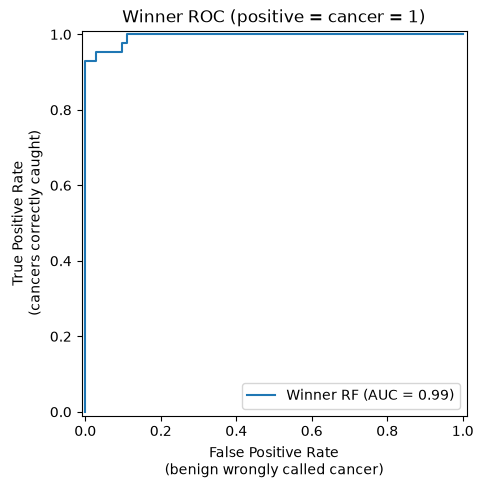

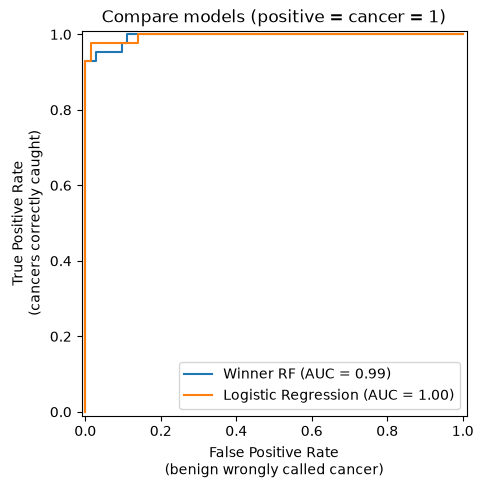

Logged artifacts: winner_roc.png , compare_roc.png
Open the UI from this folder:
  mlflow ui
Then: experiment 'bc-classifier' → run 'winner_with_plots' → Artifacts


In [ ]:
# Best run so far (from the table above), sorted by F1 for cancer
best = runs.iloc[0]
depth_raw = best["params.max_depth"]
max_depth = None if str(depth_raw) in ("None", "nan") else int(float(depth_raw))
n_estimators = int(float(best["params.n_estimators"]))
best_cfg = dict(n_estimators=n_estimators, max_depth=max_depth)

print(
    "Winner from logged runs:",
    f"max_depth={max_depth}, n_estimators={n_estimators},",
    f"F1={best['metrics.f1']:.4f}, AUC={best['metrics.roc_auc']:.4f}",
)

# Logistic baseline for the comparison plot (same labels: 1 = cancer)
lr_cmp = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000)),
]).fit(X_train, y_train)

with mlflow.start_run(run_name="winner_with_plots"):
    m = RandomForestClassifier(random_state=42, **best_cfg).fit(X_train, y_train)
    f1 = f1_score(y_test, m.predict(X_test))
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])

    mlflow.log_params(best_cfg)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    # 1) Winner ROC — appears under Artifacts in the MLflow UI
    fig1, ax1 = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(m, X_test, y_test, ax=ax1, pos_label=1, name="Winner RF")
    ax1.set_xlabel("False Positive Rate\n(benign wrongly called cancer)")
    ax1.set_ylabel("True Positive Rate\n(cancers correctly caught)")
    ax1.set_title("Winner ROC (positive = cancer = 1)")
    fig1.savefig("winner_roc.png", dpi=120, bbox_inches="tight")
    mlflow.log_artifact("winner_roc.png")
    plt.show()

    # 2) Forest vs logistic — second artifact (model comparison kept with the run)
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(m, X_test, y_test, ax=ax2, pos_label=1, name="Winner RF")
    RocCurveDisplay.from_estimator(lr_cmp, X_test, y_test, ax=ax2, pos_label=1, name="Logistic Regression")
    ax2.set_xlabel("False Positive Rate\n(benign wrongly called cancer)")
    ax2.set_ylabel("True Positive Rate\n(cancers correctly caught)")
    ax2.set_title("Compare models (positive = cancer = 1)")
    fig2.savefig("compare_roc.png", dpi=120, bbox_inches="tight")
    mlflow.log_artifact("compare_roc.png")
    plt.show()

print("Logged artifacts: winner_roc.png , compare_roc.png")
print("Open the UI from this folder:")
print("  mlflow ui")
print("Then: experiment 'bc-classifier' → run 'winner_with_plots' → Artifacts")


**Takeaway:** MLflow keeps the **settings**, **scores**, and **plots** together. Later you can open the UI and see *why* a run won — not only a number in the notebook.

**What you should see**
1. Notebook: winner line printed, two ROC figures
2. Terminal: `mlflow ui` then open http://localhost:5000
3. UI: run `winner_with_plots` → **Artifacts** → `winner_roc.png` and `compare_roc.png`


---
## Concept check

Try each question first. Then read the answers.

1. A fraud model is 99% accurate but finds only 5% of real fraud. Which score shows the problem?
2. Where should we fit `StandardScaler`, and why?
3. Train F1 = 0.99 but validation F1 = 0.80. Is the model too simple or too detailed? Name one fix.
4. Why do we report both `GridSearchCV.best_score_` and a separate test score?
5. Ablation: we remove a group of features and the score goes **up**. What does that mean?

**Answers (plain English)**

1. **Recall** (how many real fraud cases we caught).  
   Accuracy can look great if almost everyone is “not fraud.” The model can ignore fraud and still score 99%.

2. Fit it **inside a Pipeline**, and only on the **training** data (each CV fold’s training part).  
   If you scale using the test data, the test set “helps” the model — that is cheating (leakage).

3. The model is **too detailed (overfitting)**.  
   It memorised the training set. Fix: use a simpler model, stop trees growing so deep, or get more data.

4. They answer different questions.  
   - `best_score_` = how well the winner did while we were **choosing** settings (a bit too hopeful).  
   - **Test score** = how well it does on data we never used to choose anything (the honest number).

5. That feature group was **not helping** — it was mostly noise.  
   The model is better without it, so drop those features.


---
## Challenge (optional)

Repeat the same steps on **new data** (`sklearn.datasets.load_wine`, or `weatherAUS.csv`):

1. Stratified train/test split and a **Pipeline** (no leakage)
2. Cross-validated baseline with mean ± std
3. Validation curve (bias vs variance)
4. `GridSearchCV`, then report **test** score
5. Ablation of at least two feature groups
6. Slice analysis of the weakest subgroup
7. Log every model to MLflow and name a winner

That is the skill set for a paper critique: honest evaluation, no leakage, and reproducible runs.
